In [5]:
import math
import torch

import ase
from ase.io import read

from quests.gpu.entropy import entropy

from fairchem.core import pretrained_mlip, FAIRChemCalculator

In [10]:
path = f"/home/grethel/dev/quests/examples/gap20/Graphite.xyz"
frames = read(path, index=":")
print(len(frames))

160


In [ ]:
predictor = pretrained_mlip.get_predict_unit("uma-s-1p1", device="cuda")
calc = FAIRChemCalculator(predictor, task_name='omat')

for frame in frames:
    frame.calc = calc

    energy = frame.get_potential_energy()
    print(energy)

In [22]:
predictor.model

AveragedModel(
  (module): HydraModel(
    (backbone): eSCNMDMoeBackbone(
      (mappingReduced): CoefficientMapping(lmax=2, mmax=2)
      (SO3_grid): ModuleDict(
        (lmax_lmax): SO3_Grid(
          (mapping): CoefficientMapping(lmax=2, mmax=2)
        )
        (lmax_mmax): SO3_Grid(
          (mapping): CoefficientMapping(lmax=2, mmax=2)
        )
      )
      (sphere_embedding): Embedding(100, 128)
      (charge_embedding): ChgSpinEmbedding(
        (rand_emb): Embedding(201, 128)
      )
      (spin_embedding): ChgSpinEmbedding(
        (rand_emb): Embedding(101, 128)
      )
      (dataset_embedding): DatasetEmbedding(
        (dataset_emb_dict): ModuleDict(
          (oc20): Embedding(1, 128)
          (omol): Embedding(1, 128)
          (omat): Embedding(1, 128)
          (odac): Embedding(1, 128)
          (omc): Embedding(1, 128)
        )
      )
      (mix_csd): Linear(in_features=384, out_features=128, bias=True)
      (distance_expansion): GaussianSmearing()
      (s

In [5]:
embeddings = torch.vstack(per_atom_embeds)

In [6]:
h = 3.34138
batch_size = 12220
H = entropy(embeddings, h=h, batch_size=batch_size)
print(H.item())

0.11652065068483353


### Energy prediction

In [ ]:
energy_labels = []
energy_preds = []
for i, atom in enumerate(atoms_lst):
    energy_preds.append(atom.get_total_energy())
    energy_labels.append(frames[i].get_total_energy().item())
# print(energy_preds)
# print(energy_labels)

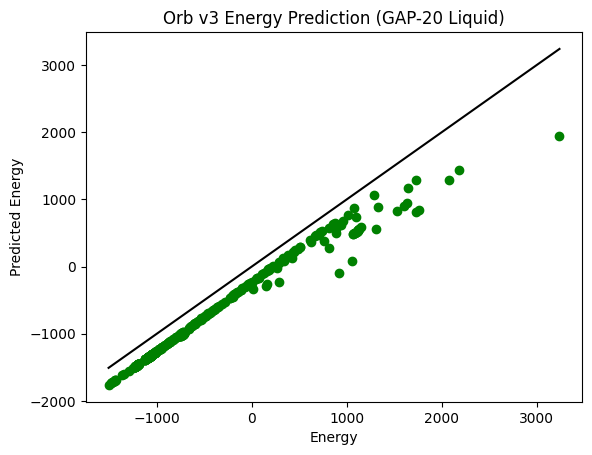

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(energy_labels, energy_preds, color='green')
plt.plot([min(energy_labels), max(energy_labels)],
         [min(energy_labels), max(energy_labels)], color='black')  # ideal line

plt.xlabel("Energy")
plt.ylabel("Predicted Energy")
plt.title("Orb v3 Energy Prediction (GAP-20 Liquid)")
plt.show()

### Un-trained model

In [2]:
import torch
from ase.io import read
from ase.build import molecule
from fairchem.core import pretrained_mlip, FAIRChemCalculator

# 1) Load pretrained predictor (this loads architecture + pretrained weights)
predictor = pretrained_mlip.get_predict_unit("uma-s-1p1", device="cpu")

# 2) Overwrite all weights with random (untrained) values
for param in predictor.model.parameters():
    param.data = torch.randn_like(param.data)

# 3) Build ASE atoms
# atoms = molecule("H2O")
# atoms.info.update({"charge": 0, "spin": 1})
atoms = read("/home/grethel/dev/quests/examples/gap20/Graphene_one_frame.xyz")
energy_label = atoms.get_potential_energy()

# 4) Attach calculator
atoms.calc = FAIRChemCalculator(predictor, task_name="omat")

# 5) Run ASE inference — these calls internally convert Atoms → batch and run model
energy = atoms.get_potential_energy()
# forces = atoms.get_forces()

print("Random model energy:", energy)
print("Label energy:", energy_label)

Random model energy: -314910.5627307191
Label energy: -1580.55839141
